<a href="https://colab.research.google.com/github/AyushNegi785/bakanae-disease-detection/blob/main/mobilenetV3_small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. File Loading ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']): # 0: Bakanae, 1: Healthy
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [ ]:
def build_mobilenet_v3_small():
    # MobileNetV3Small: Minimalist architecture for maximum speed
    base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'), # Smaller dense layer for IoT efficiency
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- MobileNetV3-Small Fold {fold+1}/{NUM_FOLDS} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx]))
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx]))

    train_ds = train_ds.map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = val_ds.map(decode_img).batch(BATCH_SIZE)

    model = build_mobilenet_v3_small()
    model.fit(train_ds, epochs=10, verbose=0)

    # Probabilities for validation
    y_true = all_labels[val_idx]
    y_probs = model.predict(val_ds).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)
    roc_curves.append((fpr, tpr, fold_auc))

    fold_results.append({
        'Fold': fold+1,
        'ACC': accuracy_score(y_true, y_pred),
        'PREC': precision_score(y_true, y_pred),
        'RECALL': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': fold_auc
    })
    all_cms.append(confusion_matrix(y_true, y_pred))

print("\nCross-Validation Training Complete.")


--- MobileNetV3-Small Fold 1/5 ---
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step

--- MobileNetV3-Small Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 969ms/step

--- MobileNetV3-Small Fold 3/5 ---


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step

--- MobileNetV3-Small Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step

--- MobileNetV3-Small Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

Cross-Validation Training Complete.



--- MobileNetV3-Small 5-Fold Summary ---
 Fold      ACC     PREC   RECALL       F1      AUC
    1 0.980861 0.961165 1.000000 0.980198 0.999816
    2 0.966507 0.980769 0.953271 0.966825 0.984332
    3 0.971154 0.978723 0.958333 0.968421 0.990792
    4 0.995192 0.991453 1.000000 0.995708 0.999531
    5 0.995192 1.000000 0.991304 0.995633 0.998878

--- Average Metrics (IoT Optimized) ---
ACC       0.981781
PREC      0.982422
RECALL    0.980582
F1        0.981357
AUC       0.994670
dtype: float64


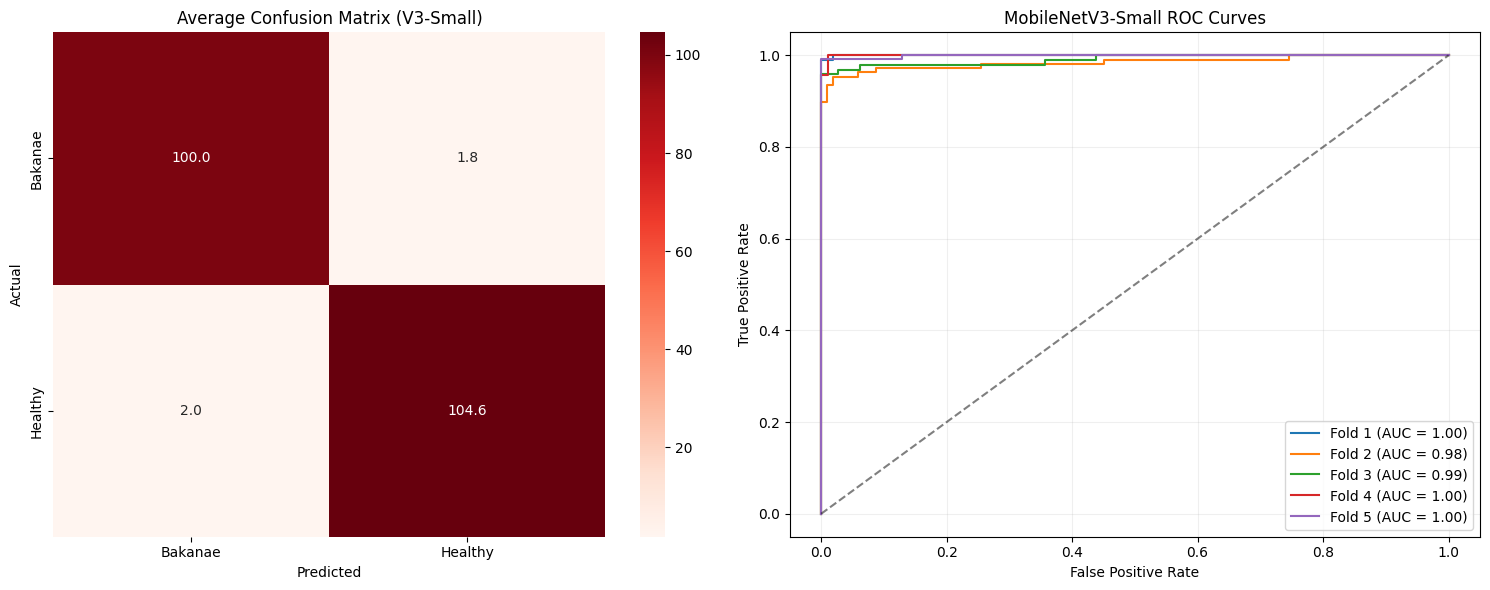

In [ ]:
# --- Summary Table ---
results_df = pd.DataFrame(fold_results)
print("\n--- MobileNetV3-Small 5-Fold Summary ---")
print(results_df.to_string(index=False))
print("\n--- Average Metrics (IoT Optimized) ---")
print(results_df[['ACC', 'PREC', 'RECALL', 'F1', 'AUC']].mean())

# --- Plotting ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
avg_cm = np.mean(all_cms, axis=0)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Average Confusion Matrix (V3-Small)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('MobileNetV3-Small ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

# --- 1. Define Paths ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_FOLDS = 5

# --- 2. Load Filepaths ---
all_filepaths = []
all_labels = []

for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_filepaths.extend(files)
    all_labels.extend([label] * len(files))

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MOBILENET-V3 SMALL MODEL PARAMETERS


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,105 (3.86 MB)

 Trainable params: 73,985 (289.00 KB)

 Non-trainable params: 939,120 (3.58 MB)



--- FOLD 1 ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step
Train Time: 462.11s | Test Time (Batch): 25.5854s
Metrics -> Acc: 0.9809 | F1: 0.9802 | Recall: 1.0000


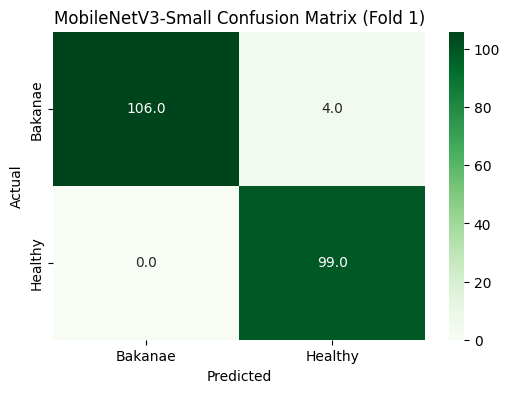


--- FOLD 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 975ms/step
Train Time: 352.77s | Test Time (Batch): 9.5146s
Metrics -> Acc: 0.9617 | F1: 0.9619 | Recall: 0.9439


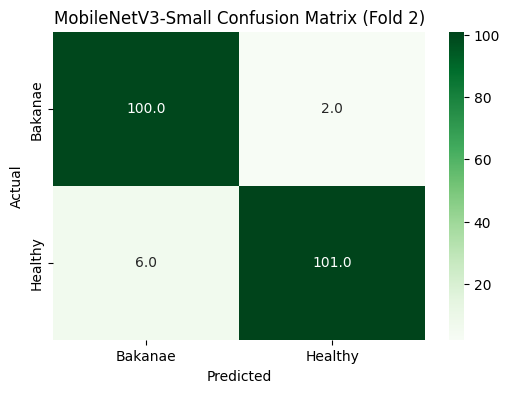


--- FOLD 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Train Time: 342.44s | Test Time (Batch): 20.4943s
Metrics -> Acc: 0.9760 | F1: 0.9735 | Recall: 0.9583


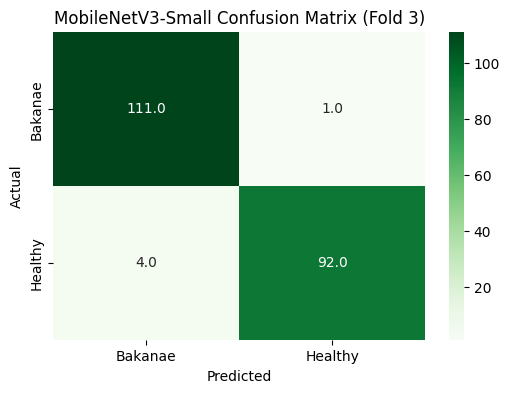


--- FOLD 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Train Time: 331.09s | Test Time (Batch): 11.5912s
Metrics -> Acc: 0.9904 | F1: 0.9914 | Recall: 0.9914


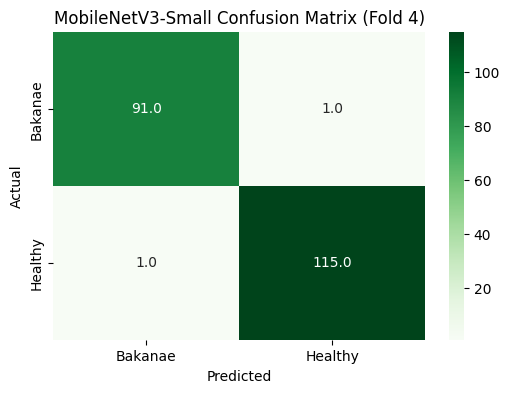


--- FOLD 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Train Time: 349.19s | Test Time (Batch): 10.2446s
Metrics -> Acc: 0.9952 | F1: 0.9956 | Recall: 0.9913


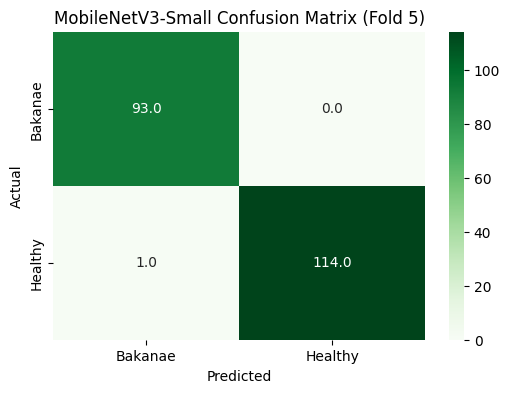

In [ ]:
def plot_cm_image(cm, title):
    plt.figure(figsize=(6, 4))
    # Using 'Greens' to distinguish MobileNet results from other models
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Greens',
                xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def build_mobilenet_v3_small():
    # Load the Small variant optimized for Edge CPUs
    base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        # Built-in preprocessing for MobileNetV3 (handles scaling to [0, 255] or [-1, 1])
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input, input_shape=(224, 224, 3)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 1. Show Parameter Breakdown
temp_model = build_mobilenet_v3_small()
print("\n" + "="*50)
print("MOBILENET-V3 SMALL MODEL PARAMETERS")
temp_model.summary()
print("="*50 + "\n")

kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []
all_cms = []
roc_curves = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n--- FOLD {fold+1} ---")

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[train_idx], all_labels[train_idx])).map(decode_img).shuffle(100).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[val_idx], all_labels[val_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_mobilenet_v3_small()

    # 2. Measure Training Duration
    start_train = time.time()
    model.fit(train_ds, epochs=10, verbose=0)
    end_train = time.time()
    train_duration = end_train - start_train

    # 3. Measure Inference (Test) Duration
    start_test = time.time()
    y_probs = model.predict(val_ds).ravel()
    end_test = time.time()
    test_duration = end_test - start_test

    y_true = all_labels[val_idx]
    y_pred = (y_probs > 0.5).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc = auc(fpr, tpr)

    print(f"Train Time: {train_duration:.2f}s | Test Time (Batch): {test_duration:.4f}s")
    print(f"Metrics -> Acc: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")

    # Print Confusion Matrix as Image after each fold
    plot_cm_image(cm, f'MobileNetV3-Small Confusion Matrix (Fold {fold+1})')

    all_cms.append(cm)
    roc_curves.append((fpr, tpr, fold_auc))
    fold_results.append({
        'ACC': acc, 'F1': f1, 'RECALL': rec, 'AUC': fold_auc,
        'TRAIN_T': train_duration, 'TEST_T': test_duration
    })


##################################################
FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V3 SMALL)
##################################################
Avg Accuracy:      0.9808
Avg F1-Score:      0.9805
Avg Recall:        0.9770
Avg AUC-ROC:       0.9950
Avg Training Time: 367.52 seconds
Avg Inference Time:15.4860 seconds per fold
##################################################


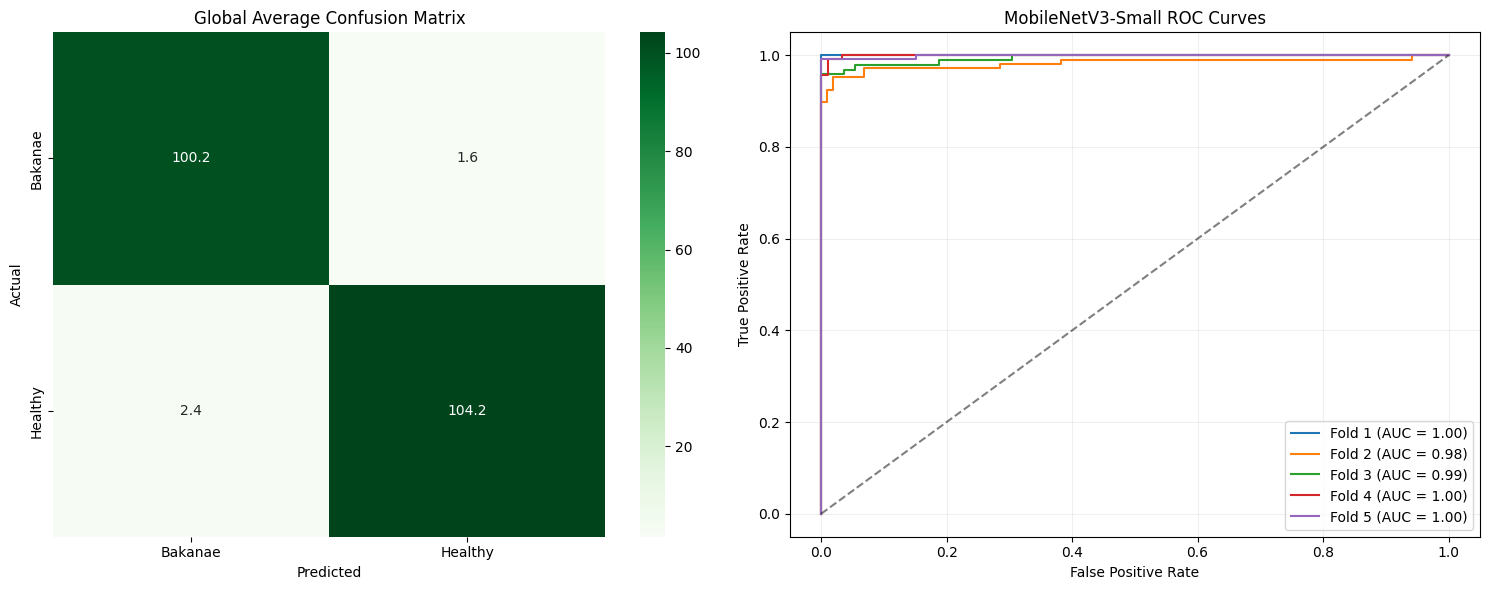

In [ ]:
results_df = pd.DataFrame(fold_results)
avg_cm = np.mean(all_cms, axis=0)

print("\n" + "#"*50)
print("FINAL GLOBAL PERFORMANCE SUMMARY (MOBILENET-V3 SMALL)")
print("#"*50)
print(f"Avg Accuracy:      {results_df['ACC'].mean():.4f}")
print(f"Avg F1-Score:      {results_df['F1'].mean():.4f}")
print(f"Avg Recall:        {results_df['RECALL'].mean():.4f}")
print(f"Avg AUC-ROC:       {results_df['AUC'].mean():.4f}")
print(f"Avg Training Time: {results_df['TRAIN_T'].mean():.2f} seconds")
print(f"Avg Inference Time:{results_df['TEST_T'].mean():.4f} seconds per fold")
print("#"*50)

# Final Visualizations
plt.figure(figsize=(15, 6))

# Avg Confusion Matrix Image
plt.subplot(1, 2, 1)
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Global Average Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Global ROC Curves
plt.subplot(1, 2, 2)
for i, (fpr, tpr, fold_auc) in enumerate(roc_curves):
    plt.plot(fpr, tpr, label=f'Fold {i+1} (AUC = {fold_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('MobileNetV3-Small ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                             f1_score, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras import layers, models, ops

# --- Configuration ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_FOLDS = 5

# --- Load Filepaths & Labels ---
all_filepaths, all_labels = [], []
for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    if os.path.exists(folder_path):
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_filepaths.extend(files)
        all_labels.extend([label] * len(files))

all_filepaths, all_labels = np.array(all_filepaths), np.array(all_labels)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label


==================== Fold 1 ====================


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ lambda[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 960)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (1, 49, 960)      │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (49, 49)          │          0 │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 49, 960)      │ 29,515,200 │ lambda_1[0][0],   │
│ (MultiHeadAttentio… │                   │            │ add_8[0][0],      │
│                     │                   │            │ add_8[0][0],      │
│                     │                   │            │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (1, 49, 960)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (1, 49, 960)      │          0 │ add_8[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (1, 49, 960)      │      1,920 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 49, 960)      │ 29,515,200 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (1, 49, 960)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (1, 49, 960)      │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 49, 960)      │      1,920 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (1, 49, 2048)     │  1,968,128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (1, 49, 960)      │  1,967,040 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (1, 49, 960)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (1, 49, 960)      │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 49, 960)      │      1,920 │ add_11[0][0]    

 Total params: 99,668,161 (380.20 MB)

 Trainable params: 96,671,809 (368.77 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1022s 19s/step - accuracy: 0.9232 - loss: 0.7210
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1031s 18s/step - accuracy: 0.8896 - loss: 1.0132
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 978s 18s/step - accuracy: 0.7983 - loss: 1.2760
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 975s 18s/step - accuracy: 0.5762 - loss: 2.1225
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 976s 18s/step - accuracy: 0.5042 - loss: 1.3618
14/14 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step


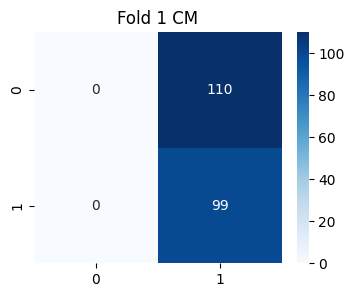


==================== Fold 2 ====================
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1007s 19s/step - accuracy: 0.9112 - loss: 0.6109
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1033s 18s/step - accuracy: 0.9112 - loss: 0.6011
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 976s 18s/step - accuracy: 0.7803 - loss: 1.4391
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 988s 19s/step - accuracy: 0.5726 - loss: 1.4664
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 972s 18s/step - accuracy: 0.4166 - loss: 1.9656
14/14 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step


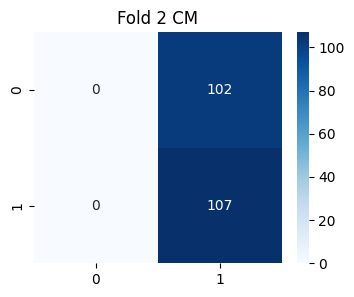


==================== Fold 3 ====================
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1008s 18s/step - accuracy: 0.9281 - loss: 0.7124
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 990s 19s/step - accuracy: 0.8801 - loss: 0.8875
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 968s 18s/step - accuracy: 0.8489 - loss: 1.1056
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1019s 19s/step - accuracy: 0.7146 - loss: 1.6897
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 982s 19s/step - accuracy: 0.7830 - loss: 1.0998
13/13 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step


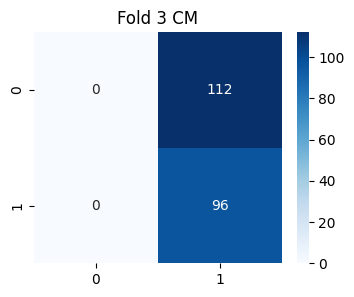


==================== Fold 4 ====================
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 993s 18s/step - accuracy: 0.9101 - loss: 0.7387
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 990s 19s/step - accuracy: 0.9053 - loss: 0.6642
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1005s 19s/step - accuracy: 0.7986 - loss: 1.4774
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1009s 19s/step - accuracy: 0.5683 - loss: 2.0805
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1048s 19s/step - accuracy: 0.5336 - loss: 1.9526
13/13 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step


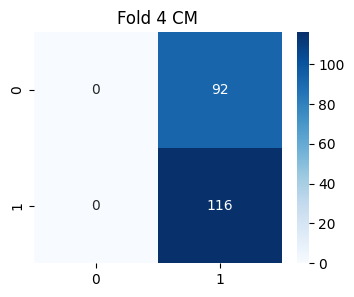


==================== Fold 5 ====================
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1042s 19s/step - accuracy: 0.9233 - loss: 0.8826
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 971s 18s/step - accuracy: 0.8861 - loss: 0.9477
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 998s 19s/step - accuracy: 0.7590 - loss: 1.1722
Epoch 4/5
 2/53 ━━━━━━━━━━━━━━━━━━━━ 22:48 27s/step - accuracy: 0.0000e+00 - loss: 7.3110

In [ ]:
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    def create_causal_mask(inputs):
        seq_len = ops.shape(inputs)[1]
        mask = ops.tril(ops.ones((seq_len, seq_len)))
        return ops.cast(mask, dtype="bool")

    causal_mask = layers.Lambda(create_causal_mask)(x)

    # 1. Masked Multi-Head Attention Branch
    attn_mmha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(
        query=x, value=x, key=x, attention_mask=causal_mask
    )
    outMMHA = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, layers.Dropout(dropout)(attn_mmha)]))

    # 2. Standard Multi-Head Attention Branch
    attn_mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(outMMHA, outMMHA)
    outMHA = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([outMMHA, layers.Dropout(dropout)(attn_mha)]))

    # 3. Feed Forward (FFN)
    ffn = layers.Dense(ff_dim, activation="relu")(outMHA)
    ffn = layers.Dense(embed_dim)(ffn)
    outFF = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([outMHA, layers.Dropout(dropout)(ffn)]))

    # 4. Cross-Attention Style Final Block
    attn_final = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(outMMHA, outFF)
    outFN = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([outMMHA, layers.Dropout(dropout)(attn_final)]))

    # 5. Final Feed Forward
    ffn_final = layers.Dense(ff_dim, activation="relu")(outFN)
    ffn_final = layers.Dense(embed_dim)(ffn_final)
    return layers.LayerNormalization(epsilon=1e-6)(layers.Add()([outFN, layers.Dropout(dropout)(ffn_final)]))

def build_hybrid_model():
    inputs = layers.Input(shape=(224, 224, 3))
    prep = layers.Lambda(lambda x: tf.keras.applications.mobilenet_v3.preprocess_input(x))(inputs)

    backbone = tf.keras.applications.MobileNetV3Large(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    backbone.trainable = False

    x = backbone(prep) # (Batch, 7, 7, 960)
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h * w, c))(x)

    # Positional Encoding
    num_patches = h * w
    pos_indices = ops.arange(start=0, stop=num_patches, step=1)
    pos_emb = layers.Embedding(input_dim=h*w, output_dim=c)(tf.range(start=0, limit=h*w, delta=1))
    pos_emb = tf.expand_dims(pos_emb, axis=0)  # (1, 49, 960)
    x = layers.Add()([x, pos_emb])

    # Transformer
    x = transformer_block(x, embed_dim=c, num_heads=8, ff_dim=2048)

    # CRITICAL: Pooling to collapse the 49 tokens into 1 vector per image
    x = layers.GlobalAveragePooling1D()(x) # This turns (Batch, 49, 960) -> (Batch, 960)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="diagnosis_output")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- 5-Fold Training Loop ---
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results, all_cms, roc_data = [], [], []

for fold, (t_idx, v_idx) in enumerate(kf.split(all_filepaths)):
    print(f"\n" + "="*20 + f" Fold {fold+1} " + "="*20)

    train_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[t_idx], all_labels[t_idx])).map(decode_img).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((all_filepaths[v_idx], all_labels[v_idx])).map(decode_img).batch(BATCH_SIZE)

    model = build_hybrid_model()
    if fold == 0: model.summary()

    start_train = time.time()
    model.fit(train_ds, epochs=5, verbose=1)
    train_time = time.time() - start_train

    start_test = time.time()
    y_probs = model.predict(val_ds).ravel()
    test_time = time.time() - start_test

    y_true, y_pred = all_labels[v_idx], (y_probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    all_cms.append(cm)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Fold {fold+1} CM"); plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_data.append((fpr, tpr, auc(fpr, tpr)))
    fold_results.append({'acc': accuracy_score(y_true, y_pred), 'f1': f1_score(y_true, y_pred),
                         'rec': recall_score(y_true, y_pred), 'tr_t': train_time, 'ts_t': test_time})